**Neural Networks & Reproducible**

In [1]:
import os
seed = 42
os.environ['PYTHONHASHSEED']=str(seed)

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [3]:
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [4]:
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1,22)] 
col_names = index_names + setting_names + sensor_names

train = pd.read_csv("train_FD001.txt", sep='\s+', header=None, names=col_names)
test = pd.read_csv("test_FD001.txt", sep='\s+', header=None, names=col_names)
y_test = pd.read_csv("RUL_FD001.txt", sep='\s+', header=None, names=['RUL'])

In [5]:
print(train.shape)
train.head()

(20631, 26)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
def add_remaining_useful_life(df):
   
    grouped_by_unit = df.groupby(by="unit_nr")
    max_cycle = grouped_by_unit["time_cycles"].max()
    
    
    result_frame = df.merge(max_cycle.to_frame(name='max_cycle'), left_on='unit_nr', right_index=True)
    
  
    remaining_useful_life = result_frame["max_cycle"] - result_frame["time_cycles"]
    result_frame["RUL"] = remaining_useful_life
    
  
    result_frame = result_frame.drop("max_cycle", axis=1)
    return result_frame

train = add_remaining_useful_life(train)
train[index_names+['RUL']].head()

,unit_nr,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [7]:
X_train = train[sensor_names].copy()
y_train = train['RUL'].copy()
y_train_clipped = y_train.clip(upper=125)

X_test = test.drop(['time_cycles']+setting_names, axis=1).groupby('unit_nr').last().copy()  

In [8]:
scaler = MinMaxScaler()
scaler.fit(X_train[sensor_names])
X_train_scaled = X_train.copy()
X_train_scaled[sensor_names] = pd.DataFrame(scaler.transform(X_train[sensor_names]), columns=sensor_names)


X_test_scaled = X_test.copy()
X_test_scaled[sensor_names] = pd.DataFrame(scaler.transform(X_test[sensor_names]), columns=sensor_names, index=X_test.index)

In [9]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.80, random_state=42)  

def train_val_group_split(X, y, gss, groups, print_groups=True):
    
    for idx_train, idx_val in gss.split(X, y, groups=groups):
        if print_groups:
            print('train_split_engines', train.iloc[idx_train]['unit_nr'].unique(), '\n')
            print('validate_split_engines', train.iloc[idx_val]['unit_nr'].unique(), '\n')

        X_train_split = X.iloc[idx_train].copy()
        y_train_split = y.iloc[idx_train].copy()
        X_val_split = X.iloc[idx_val].copy()
        y_val_split = y.iloc[idx_val].copy()
    return X_train_split, y_train_split, X_val_split, y_val_split

split_result = train_val_group_split(X_train_scaled, y_train_clipped, gss, train['unit_nr'], print_groups=True)
X_train_split_scaled, y_train_clipped_split_scaled, X_val_split_scaled, y_val_clipped_split_scaled = split_result

train_split_engines [  2   3   4   6   7   8   9  10  12  14  15  16  17  18  20  21  22  24
  25  26  27  28  29  30  33  35  36  37  38  39  41  42  43  44  47  48
  49  50  51  52  53  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  72  73  75  76  79  80  82  83  85  86  87  88  89  90  92
  93  94  95  96  97  98  99 100] 

validate_split_engines [ 1  5 11 13 19 23 31 32 34 40 45 46 54 71 74 77 78 81 84 91] 



In [10]:
train_cols = sensor_names 
input_dim = len(train_cols)

model = Sequential()
model.add(Dense(16, input_dim=input_dim, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))

In [11]:
model.compile(loss='mean_squared_error', optimizer='adam')
model.save_weights('reproducible_primer_weights.h5')

In [12]:
epochs = 20

model.compile(loss='mean_squared_error', optimizer='adam')
model.load_weights('reproducible_primer_weights.h5')

history = model.fit(X_train_split_scaled[train_cols], y_train_clipped_split_scaled,
                    validation_data=(X_val_split_scaled[train_cols], y_val_clipped_split_scaled),
                    epochs=epochs)

Epoch 1/20
518/518 [==============================] - 2s 2ms/step - loss: 2244.5439 - val_loss: 396.6262
Epoch 2/20
518/518 [==============================] - 1s 2ms/step - loss: 427.6800 - val_loss: 362.7304
Epoch 3/20
518/518 [==============================] - 1s 1ms/step - loss: 406.0523 - val_loss: 344.7246
Epoch 4/20
518/518 [==============================] - 1s 1ms/step - loss: 394.8299 - val_loss: 342.0038
Epoch 5/20
518/518 [==============================] - 1s 1ms/step - loss: 388.6579 - val_loss: 323.7076
Epoch 6/20
518/518 [==============================] - 1s 1ms/step - loss: 383.1805 - val_loss: 329.7699
Epoch 7/20
518/518 [==============================] - 1s 1ms/step - loss: 379.5383 - val_loss: 322.9517
Epoch 8/20
518/518 [==============================] - 1s 1ms/step - loss: 374.0047 - val_loss: 312.2318
Epoch 9/20
518/518 [==============================] - 1s 2ms/step - loss: 369.0759 - val_loss: 303.5805
Epoch 10/20
518/518 [==============================] - 1s 2ms/s

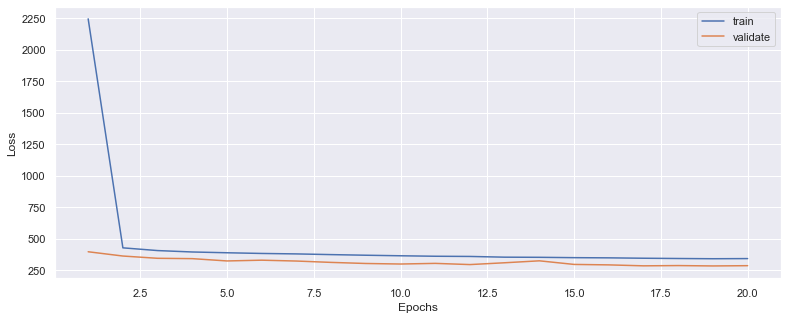

In [13]:
def plot_loss(fit_history):
    plt.figure(figsize=(15,6))
    plt.plot(range(1, len(fit_history.history['loss'])+1), fit_history.history['loss'], label='train')
    plt.plot(range(1, len(fit_history.history['val_loss'])+1), fit_history.history['val_loss'], label='validate')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(history)

In [14]:
def evaluate(y_true, y_hat, label='test'):
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    variance = r2_score(y_true, y_hat)
    print('{} set RMSE:{}, R2:{}'.format(label, rmse, variance))

In [15]:
y_hat_train = model.predict(X_train_scaled[train_cols])
evaluate(y_train_clipped, y_hat_train, 'train')

# y_hat_test = model.predict(X_test_scaled[train_cols])
# evaluate(y_test, y_hat_test)

train set RMSE:18.10583555943848, R2:0.8112295129469766


In [16]:
def exponential_smoothing(df, sensors, n_samples, alpha=0.4):
    df = df.copy()
    
    df[sensors] = df.groupby('unit_nr')[sensors].apply(lambda x: x.ewm(alpha=alpha).mean())
    
    def create_mask(data, samples):
        result = np.ones_like(data)
        result[0:samples] = 0
        return result
    
    mask = df.groupby('unit_nr')['unit_nr'].transform(create_mask, samples=n_samples).astype(bool)
    df = df[mask]
    
    return df

In [17]:
alpha = 0.4

X_train_interim = train[index_names + sensor_names].copy()
X_test_interim = test[index_names + sensor_names].copy()

X_train_interim[sensor_names] = pd.DataFrame(scaler.transform(X_train_interim[sensor_names]), columns=sensor_names)
X_test_interim[sensor_names] = pd.DataFrame(scaler.transform(X_test_interim[sensor_names]), columns=sensor_names)

X_train_interim = exponential_smoothing(X_train_interim, sensor_names, 0, alpha)
X_test_interim = exponential_smoothing(X_test_interim, sensor_names, 0, alpha)

X_train_smooth = X_train_interim.drop(index_names, axis=1)
X_test_smooth = X_test_interim.drop('time_cycles', axis=1).groupby('unit_nr').last().copy()

In [18]:
split_result = train_val_group_split(X_train_smooth, y_train_clipped, gss, train['unit_nr'], print_groups=False)
X_train_split_smooth, y_train_clipped_split_smooth, X_val_split_smooth, y_val_clipped_split_smooth = split_result

In [19]:
model.compile(loss='mean_squared_error', optimizer='adam')
model.load_weights('reproducible_primer_weights.h5')

history = model.fit(X_train_split_smooth[train_cols], y_train_clipped_split_smooth,
                    validation_data=(X_val_split_smooth[train_cols], y_val_clipped_split_smooth),
                    epochs=epochs)

Epoch 1/20
518/518 [==============================] - 1s 2ms/step - loss: 2253.5105 - val_loss: 384.4156
Epoch 2/20
518/518 [==============================] - 1s 2ms/step - loss: 400.8159 - val_loss: 332.2029
Epoch 3/20
518/518 [==============================] - 1s 1ms/step - loss: 365.3989 - val_loss: 300.4857
Epoch 4/20
518/518 [==============================] - 1s 1ms/step - loss: 347.1341 - val_loss: 289.0304
Epoch 5/20
518/518 [==============================] - 1s 1ms/step - loss: 336.6431 - val_loss: 273.4833
Epoch 6/20
518/518 [==============================] - 1s 1ms/step - loss: 331.2103 - val_loss: 276.8169
Epoch 7/20
518/518 [==============================] - 1s 1ms/step - loss: 330.2968 - val_loss: 270.8133
Epoch 8/20
518/518 [==============================] - 1s 2ms/step - loss: 327.3752 - val_loss: 270.4101
Epoch 9/20
518/518 [==============================] - 1s 2ms/step - loss: 325.3729 - val_loss: 269.7206
Epoch 10/20
518/518 [==============================] - 1s 2ms/s

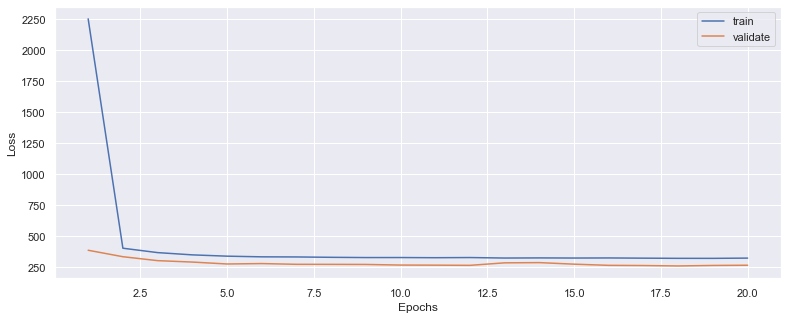

In [20]:
plot_loss(history)

In [21]:
y_hat_train = model.predict(X_train_smooth[train_cols])
evaluate(y_train_clipped, y_hat_train, 'train')

train set RMSE:17.482974753257118, R2:0.8239939429714258


In [22]:
y_hat_test = model.predict(X_test_smooth[train_cols])
evaluate(y_test, y_hat_test)

test set RMSE:18.79197159721689, R2:0.7955038431908197
